# A 股多因子研究项目示例

这个 notebook 演示一个基础但完整的量化研究流程：数据清洗、数据分析、因子挖掘、因子检验、多因子合成和简单回测。默认读取本地 baostock 面板数据，不需要联网。

In [8]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR))

from scripts.data_processing import load_panel, clean_daily_panel, data_quality_report
from scripts.analysis import panel_overview, daily_market_stats, ticker_summary
from scripts.factors import build_factor_panel
from scripts.factor_evaluation import (
    calc_daily_ic,
    summarize_ic,
    quantile_return_analysis,
    combine_factors_by_ic,
)
from scripts.backtest import run_long_short_backtest

RAW_PATH = PROJECT_DIR / "data" / "raw" / "stocks_panel_daily_qfq_baostock.csv"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")

## 1. 数据读取与清洗

In [9]:
raw = load_panel(RAW_PATH)
clean = clean_daily_panel(raw, min_obs_ratio=0.8)
clean.to_csv(PROCESSED_DIR / "clean_daily_data.csv", index=False, encoding="utf-8-sig")

print(raw.shape, clean.shape)
clean.head()

(468054, 10) (387037, 10)


,date,ticker,open,high,low,close,volume,amount,pct_change,turnover
0,2016-01-04,300014,8.366130,8.562625,7.441599,7.441599,25489850,798210864.0,-9.9939,7.478224
1,2016-01-05,300014,6.809289,7.368543,6.698446,6.965477,26888282,747134080.0,-6.3981,7.888496
2,2016-01-06,300014,7.053648,7.209836,6.726157,7.119146,18662403,519007456.0,2.2062,5.475184
3,2016-01-07,300014,6.932728,6.932728,6.406224,6.406224,4715300,123887092.0,-10.0142,1.383377
4,2016-01-08,300014,6.600199,6.650582,5.771396,6.212249,21993797,544573648.0,-3.0279,6.452550


In [10]:
report = data_quality_report(clean)
print("rows:", report["rows"])
print("tickers:", report["tickers"])
print("date range:", report["start_date"], "->", report["end_date"])
report["missing_ratio"]

rows: 387037
tickers: 162
date range: 2016-01-04 00:00:00 -> 2025-12-31 00:00:00


date          0.0
ticker        0.0
open          0.0
high          0.0
low           0.0
close         0.0
volume        0.0
amount        0.0
pct_change    0.0
turnover      0.0
dtype: float64

## 2. 基础分析

In [11]:
overview = panel_overview(clean)
overview

{'rows': 387037,
 'tickers': 162,
 'start_date': Timestamp('2016-01-04 00:00:00'),
 'end_date': Timestamp('2025-12-31 00:00:00'),
 'trading_days': 2430,
 'avg_names_per_day': np.float64(159.27448559670782)}

In [12]:
market = daily_market_stats(clean)
market[["date", "n_stocks", "equal_weight_ret", "total_amount"]].head()

,date,n_stocks,equal_weight_ret,total_amount
0,2016-01-04,143,NaN,6.526157e+10
1,2016-01-05,143,-0.002512,8.860841e+10
2,2016-01-06,143,0.027308,7.646395e+10
3,2016-01-07,143,-0.079401,2.171487e+10
4,2016-01-08,143,0.024582,9.654146e+10


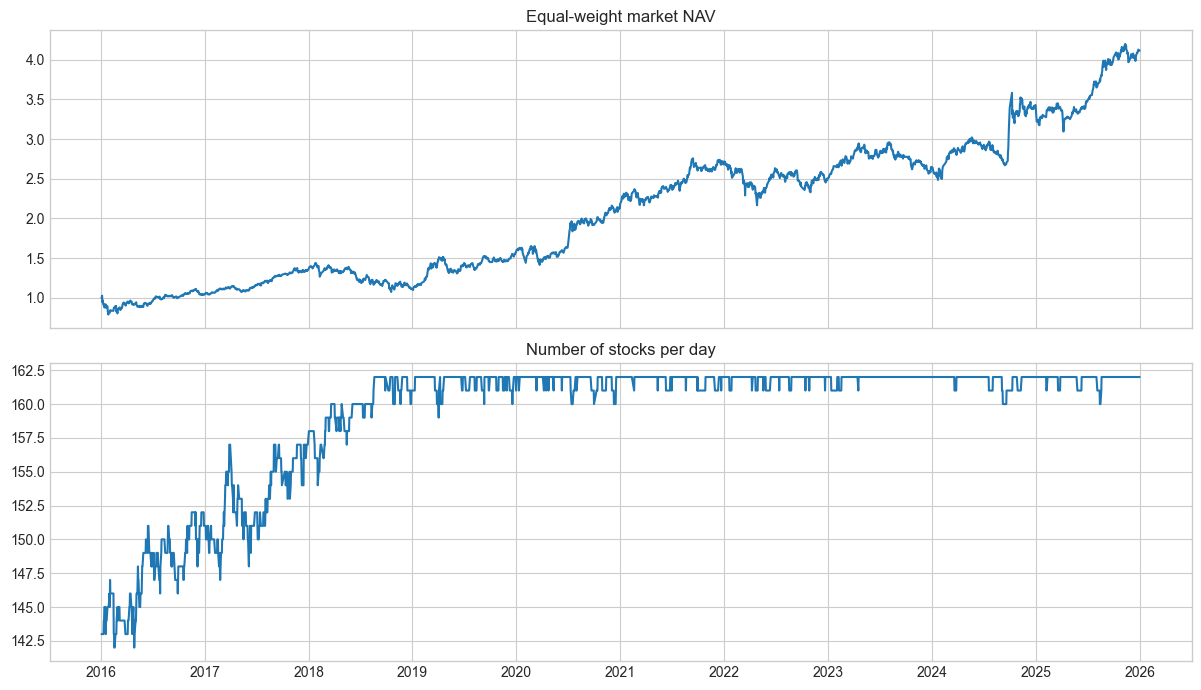

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(market["date"], (1 + market["equal_weight_ret"].fillna(0)).cumprod())
axes[0].set_title("Equal-weight market NAV")
axes[1].plot(market["date"], market["n_stocks"])
axes[1].set_title("Number of stocks per day")
plt.tight_layout()

## 3. 因子挖掘与构建

这里构建一组日频价格量价因子，并按日期进行 winsorize 与 z-score 标准化。

In [14]:
factor_panel, factor_cols = build_factor_panel(clean)
factor_panel.to_csv(PROCESSED_DIR / "factor_panel.csv", index=False, encoding="utf-8-sig")

factor_cols

['rev_20d_z',
 'mom_120_20d_z',
 'lowvol_20d_z',
 'lowvol_60d_z',
 'liq_20d_z',
 'turnover_20d_z',
 'trend_20_120d_z',
 'amplitude_20d_z',
 'volume_ratio_20d_z',
 'price_to_120d_high_z',
 'log_amount_z']

In [15]:
factor_panel[["date", "ticker", "ret_1d", "fwd_ret_20d"] + factor_cols].dropna().head()

,date,ticker,ret_1d,fwd_ret_20d,rev_20d_z,mom_120_20d_z,lowvol_20d_z,lowvol_60d_z,liq_20d_z,turnover_20d_z,trend_20_120d_z,amplitude_20d_z,volume_ratio_20d_z,price_to_120d_high_z,log_amount_z
120,2016-07-01,300014,0.000926,-0.105482,-1.733073,2.252521,-2.550142,-2.361713,3.195870,3.418340,4.508554,1.994516,-0.807298,0.242522,1.639441
121,2016-07-04,300014,0.026602,-0.113339,-1.065888,2.914696,-2.387384,-2.311929,3.039545,2.926893,4.518583,1.486622,-1.159720,0.299459,1.397008
122,2016-07-05,300014,0.073457,-0.172334,-1.864924,2.784281,-2.655042,-2.385819,3.164178,3.144930,4.587937,1.287706,0.173038,0.822682,2.262307
123,2016-07-06,300014,0.002939,-0.186061,-0.575165,2.998948,-2.174601,-2.356833,3.153668,3.238069,4.629641,0.718839,0.134888,0.843904,2.227520
124,2016-07-07,300014,0.085182,-0.229894,-1.175780,3.286879,-2.434614,-2.391811,3.151869,3.343857,4.619938,0.939241,0.487513,1.082412,2.377959


## 4. 因子检验

使用 Spearman IC 衡量因子截面排序与未来 20 日收益之间的关系。

In [16]:
ic = calc_daily_ic(factor_panel, factor_cols, forward_return_col="fwd_ret_20d")
ic_summary = summarize_ic(ic)

ic.to_csv(PROCESSED_DIR / "factor_ic_daily.csv", index=False, encoding="utf-8-sig")
ic_summary.to_csv(PROCESSED_DIR / "factor_ic_summary.csv", index=False, encoding="utf-8-sig")

ic_summary

,factor,ic_mean,ic_std,ic_ir,t_stat,p_value,positive_ratio,n_days
1,liq_20d_z,-0.049679,0.181399,-0.273864,-13.391361,1.735455e-39,0.394396,2391
2,log_amount_z,-0.048578,0.176029,-0.275964,-13.547558,2.368573e-40,0.398340,2410
9,turnover_20d_z,-0.037589,0.266270,-0.141169,-6.902872,6.505566e-12,0.438729,2391
4,lowvol_60d_z,0.029367,0.270567,0.108539,5.261606,1.557379e-07,0.541277,2350
3,lowvol_20d_z,0.026315,0.251303,0.104716,5.119310,3.311105e-07,0.546862,2390
7,rev_20d_z,0.019206,0.188723,0.101768,4.975216,6.981346e-07,0.506695,2390
0,amplitude_20d_z,-0.017044,0.236096,-0.072189,-3.529903,4.235676e-04,0.473024,2391
5,mom_120_20d_z,0.013067,0.218149,0.059898,2.866372,4.189985e-03,0.539301,2290
8,trend_20_120d_z,-0.012001,0.210794,-0.056934,-2.725114,6.476820e-03,0.488869,2291
6,price_to_120d_high_z,0.010586,0.213602,0.049558,2.372059,1.777150e-02,0.552161,2291


In [17]:
best_factor = ic_summary.iloc[0]["factor"]
qret = quantile_return_analysis(factor_panel, best_factor, forward_return_col="fwd_ret_20d")
qret

,quantile,mean_return,std_return,count
0,1,0.019918,0.052610,2391.0
1,2,0.015358,0.050273,2391.0
2,3,0.014127,0.050506,2391.0
3,4,0.010256,0.054426,2391.0
4,5,0.011929,0.067665,2391.0


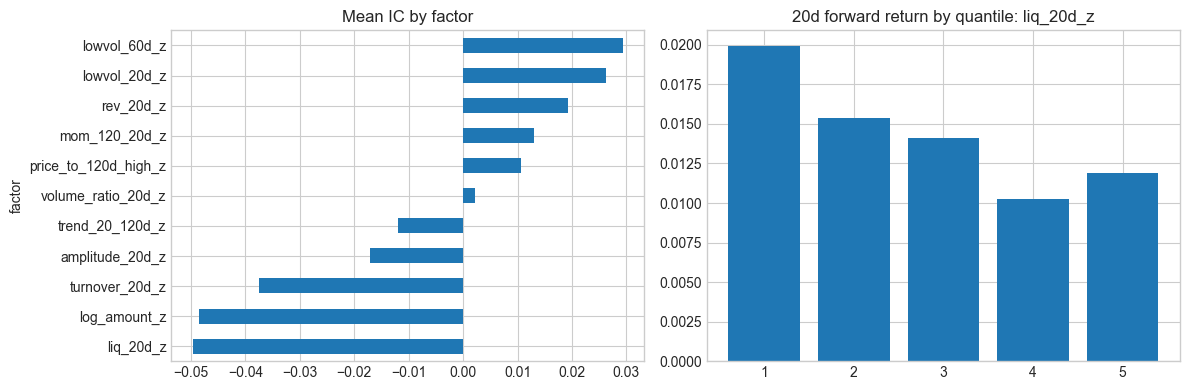

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ic.pivot(index="date", columns="factor", values="ic").mean().sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("Mean IC by factor")
axes[1].bar(qret["quantile"].astype(str), qret["mean_return"])
axes[1].set_title(f"20d forward return by quantile: {best_factor}")
plt.tight_layout()

## 5. 多因子合成与回测

使用 IC 均值作为权重方向和大小，合成综合分数。回测逻辑为 t 日形成信号，使用 t+1 日收益计算多空组合表现。

In [19]:
scored = combine_factors_by_ic(factor_panel, factor_cols, ic_summary, output_col="score")
bt, metrics = run_long_short_backtest(scored, score_col="score", fee_bps=10)

scored.to_csv(PROCESSED_DIR / "factor_panel_scored.csv", index=False, encoding="utf-8-sig")
bt.to_csv(PROCESSED_DIR / "backtest_nav.csv", index=False, encoding="utf-8-sig")

pd.Series(metrics)

annual_return      -0.111405
annual_vol          0.219310
sharpe             -0.507980
max_drawdown       -0.771003
win_rate            0.488267
avg_turnover        0.087058
total_return       -0.679696
n_days           2429.000000
dtype: float64

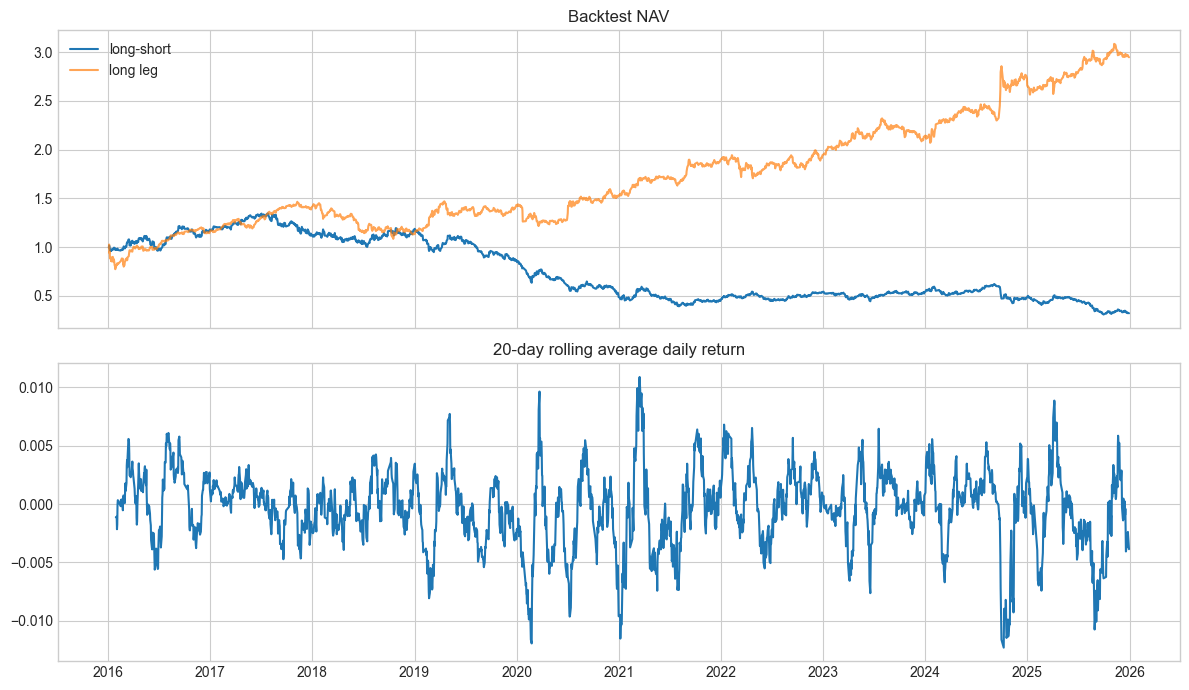

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(bt["date"], bt["nav"], label="long-short")
axes[0].plot(bt["date"], bt["long_nav"], label="long leg", alpha=0.7)
axes[0].set_title("Backtest NAV")
axes[0].legend()
axes[1].plot(bt["date"], bt["ret"].rolling(20).mean())
axes[1].set_title("20-day rolling average daily return")
plt.tight_layout()

## 6. 一键 pipeline

如果不想逐格运行，也可以直接调用完整流水线。

In [21]:
from scripts.pipeline import run_full_pipeline

# result = run_full_pipeline()
# result["ic_summary"].head(), pd.Series(result["metrics"])